Starting enhanced ball motion and audio matching process...

--- VIDEO ANALYSIS ---
Found 45 video files.
Processing video 1/45: video_only_ID_1.mp4
  - Detected 44 collisions
Processing video 2/45: video_only_ID_10.mp4
  - Detected 40 collisions
Processing video 3/45: video_only_ID_11.mp4
  - Detected 48 collisions
Processing video 4/45: video_only_ID_12.mp4
  - Detected 16 collisions
Processing video 5/45: video_only_ID_13.mp4
  - Detected 35 collisions
Processing video 6/45: video_only_ID_14.mp4
  - Detected 46 collisions
Processing video 7/45: video_only_ID_15.mp4
  - Detected 42 collisions
Processing video 8/45: video_only_ID_16.mp4
  - Detected 47 collisions
Processing video 9/45: video_only_ID_17.mp4
  - Detected 34 collisions
Processing video 10/45: video_only_ID_18.mp4
  - Detected 33 collisions
Processing video 11/45: video_only_ID_19.mp4
  - Detected 40 collisions
Processing video 12/45: video_only_ID_2.mp4
  - Detected 32 collisions
Processing video 13/45: video_only_ID_20.

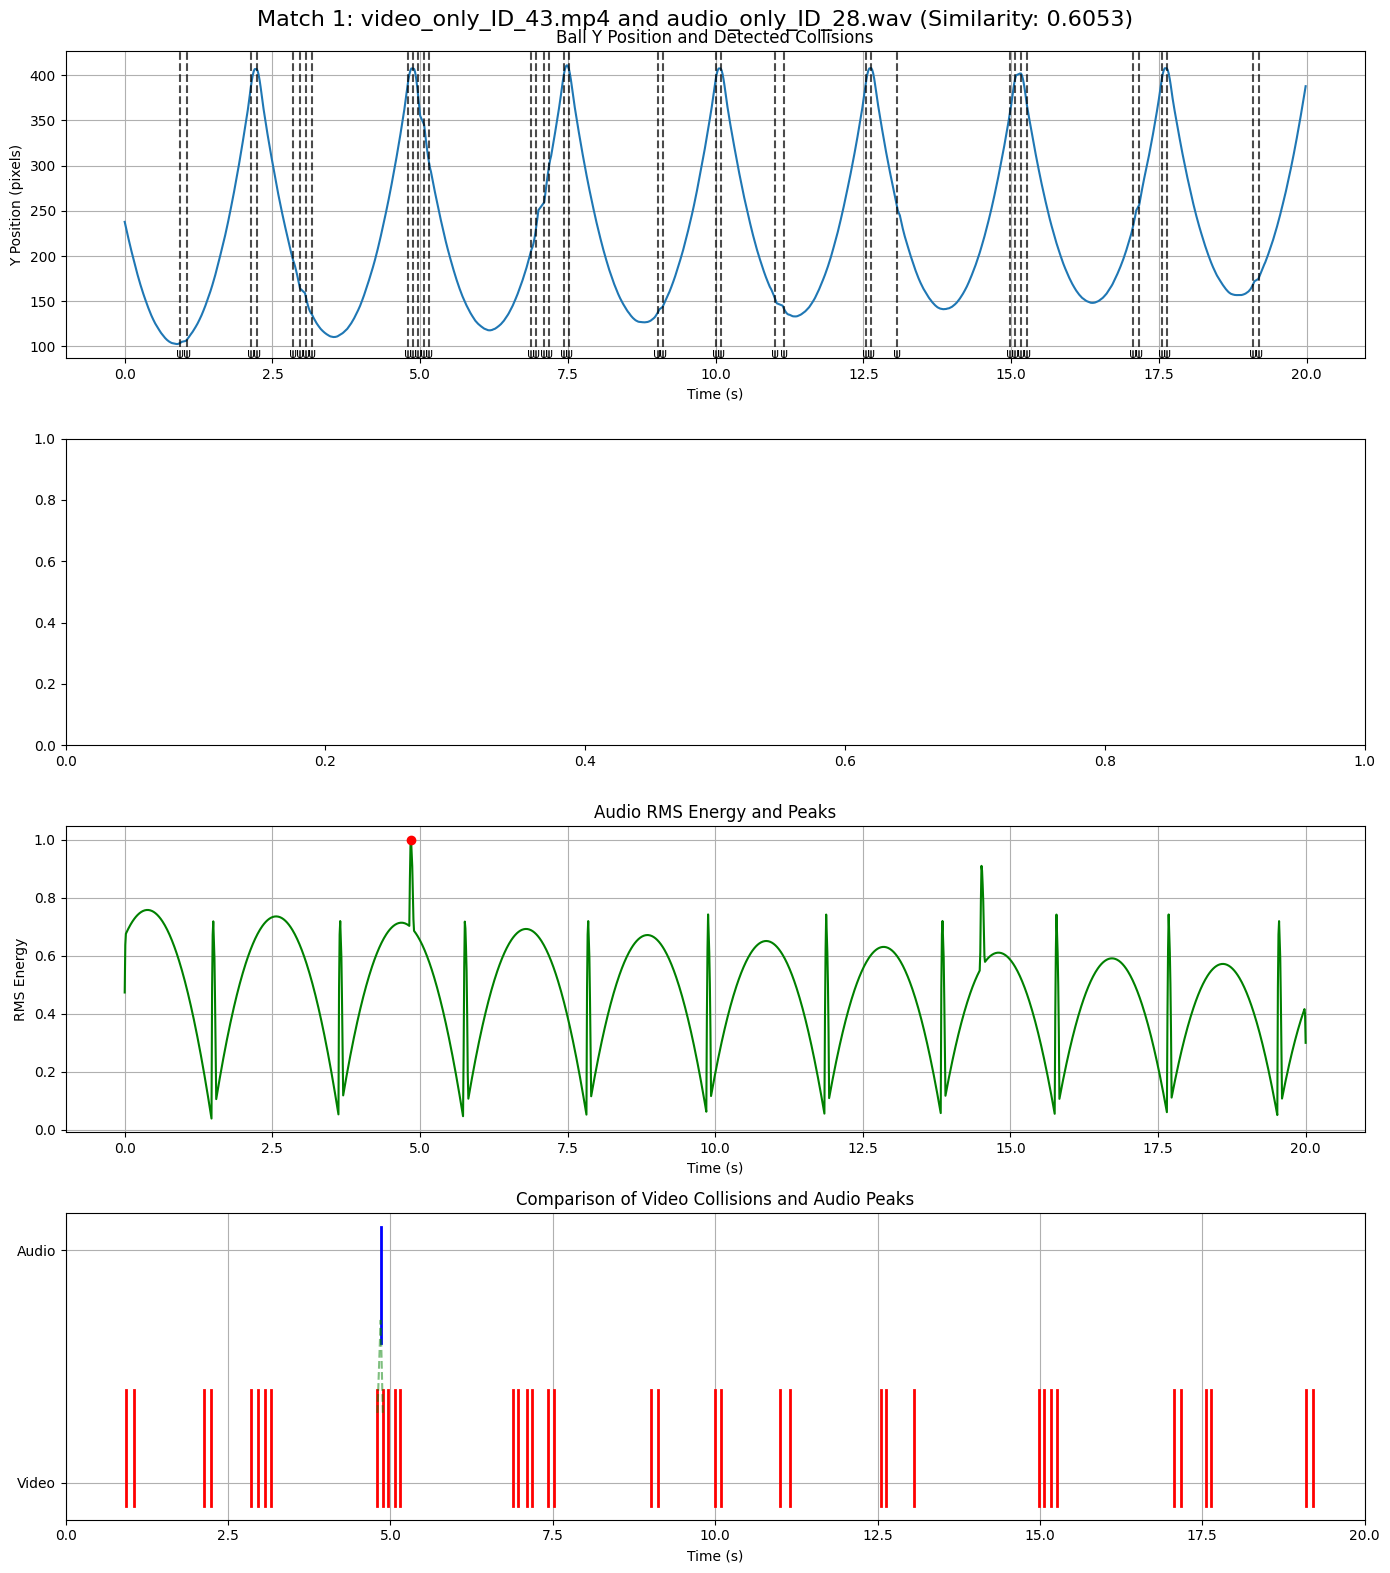

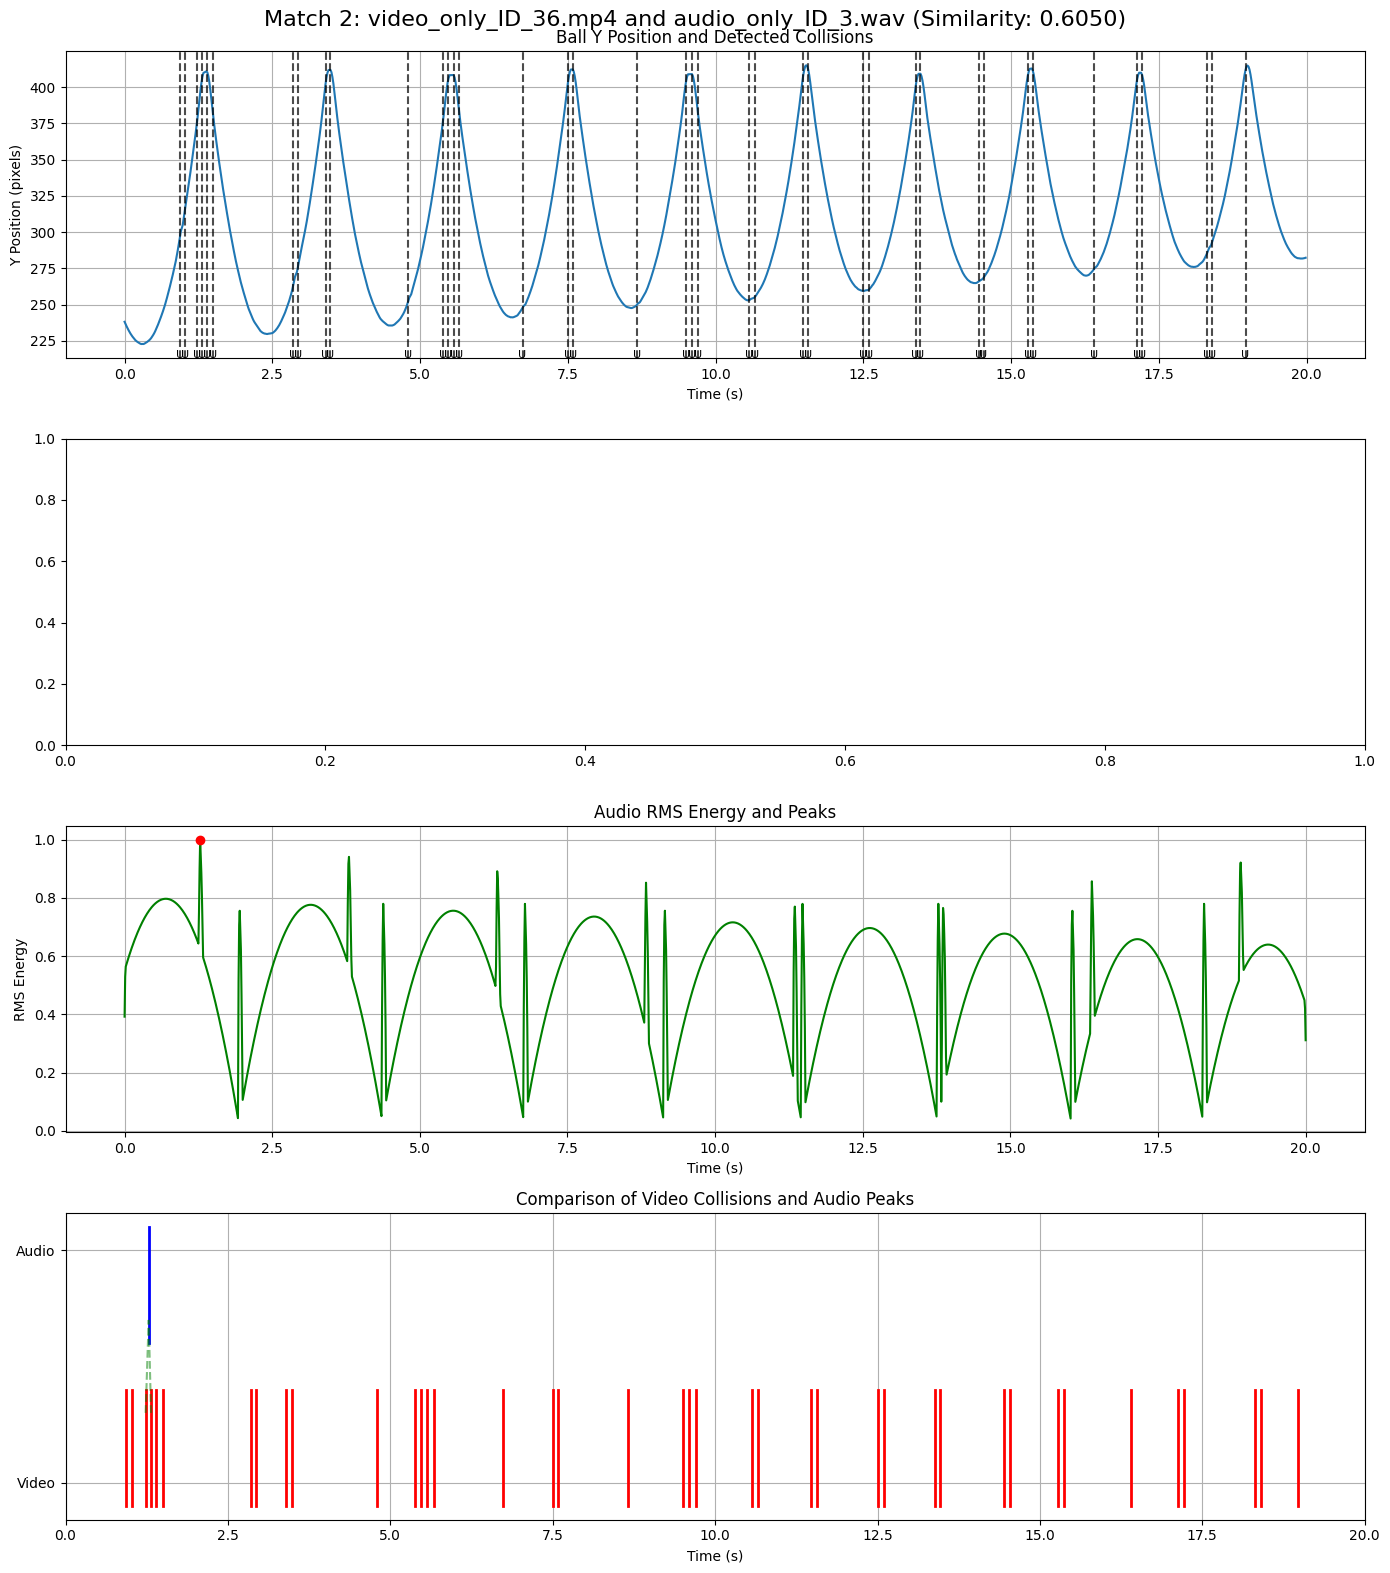

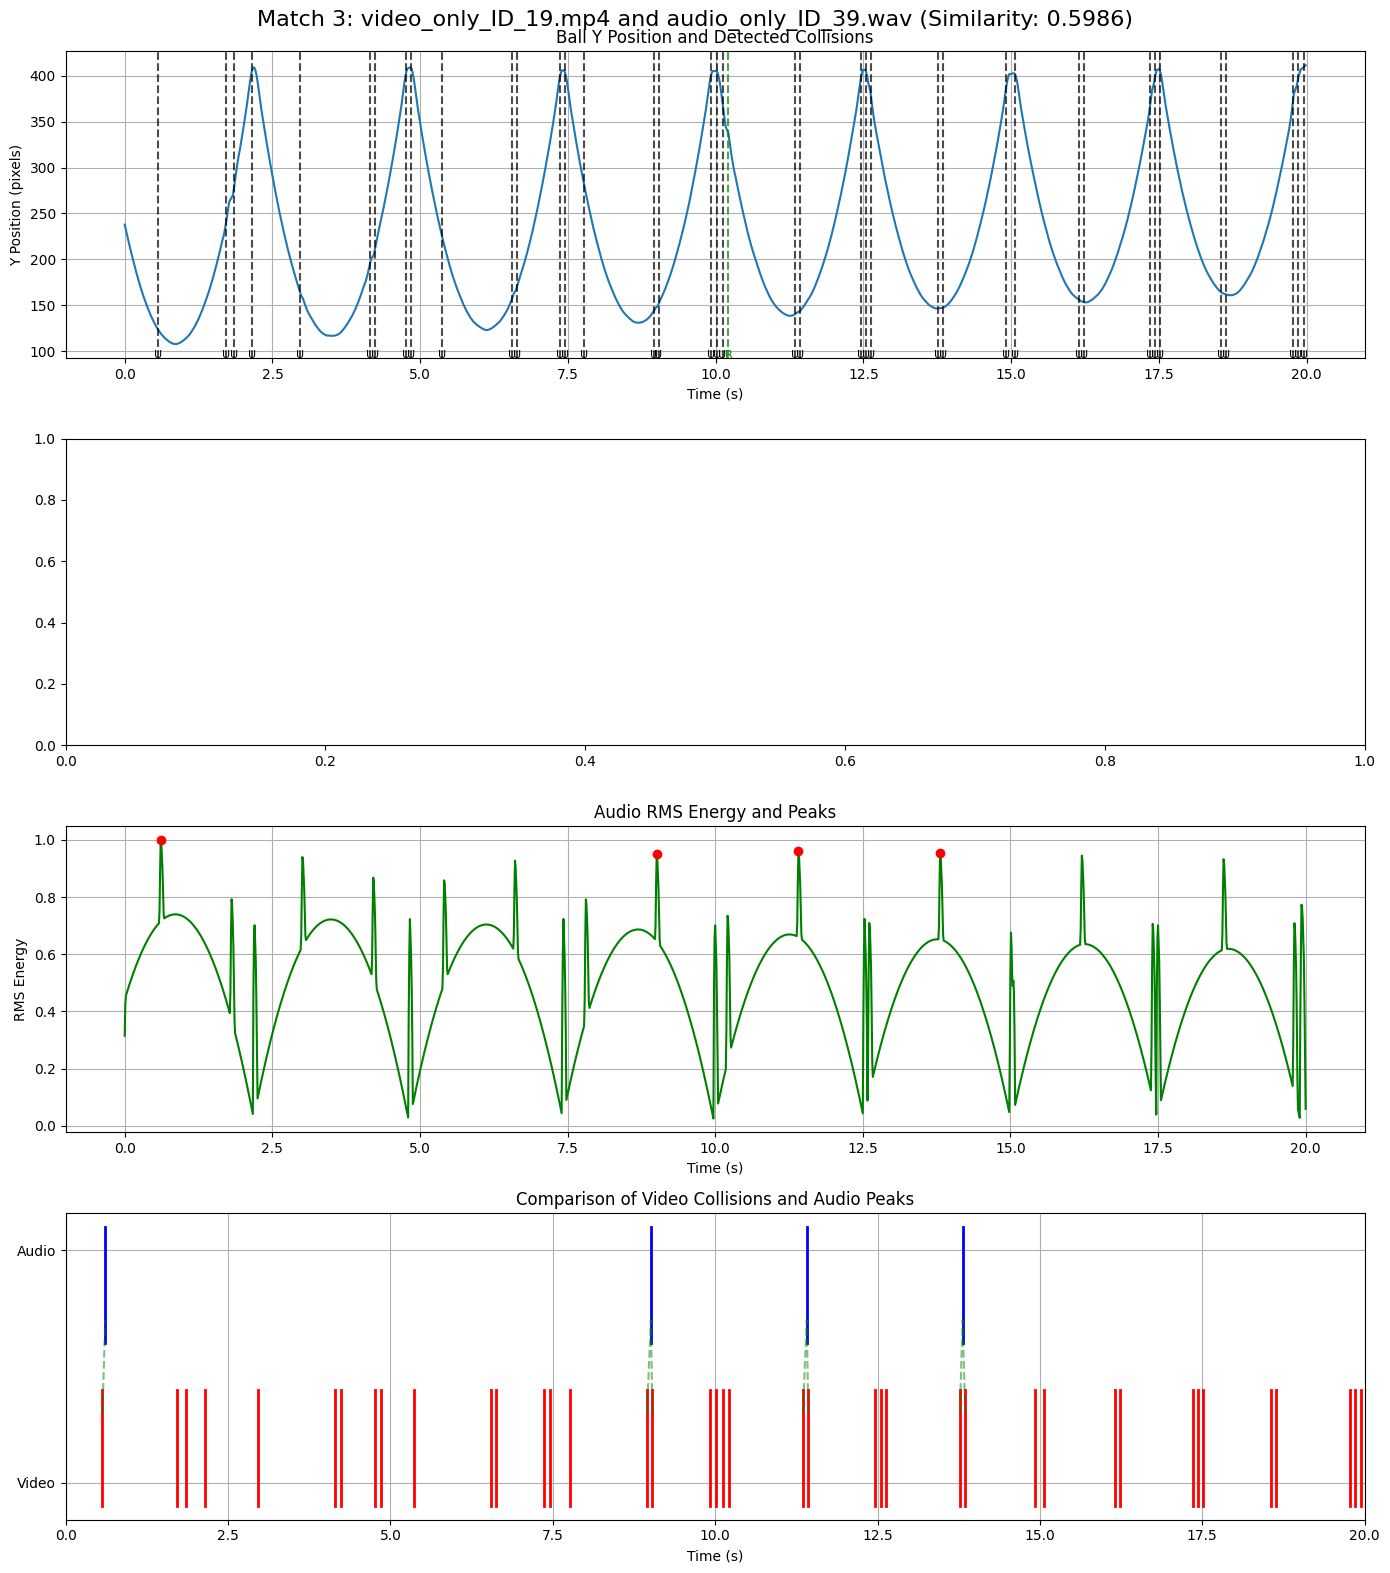

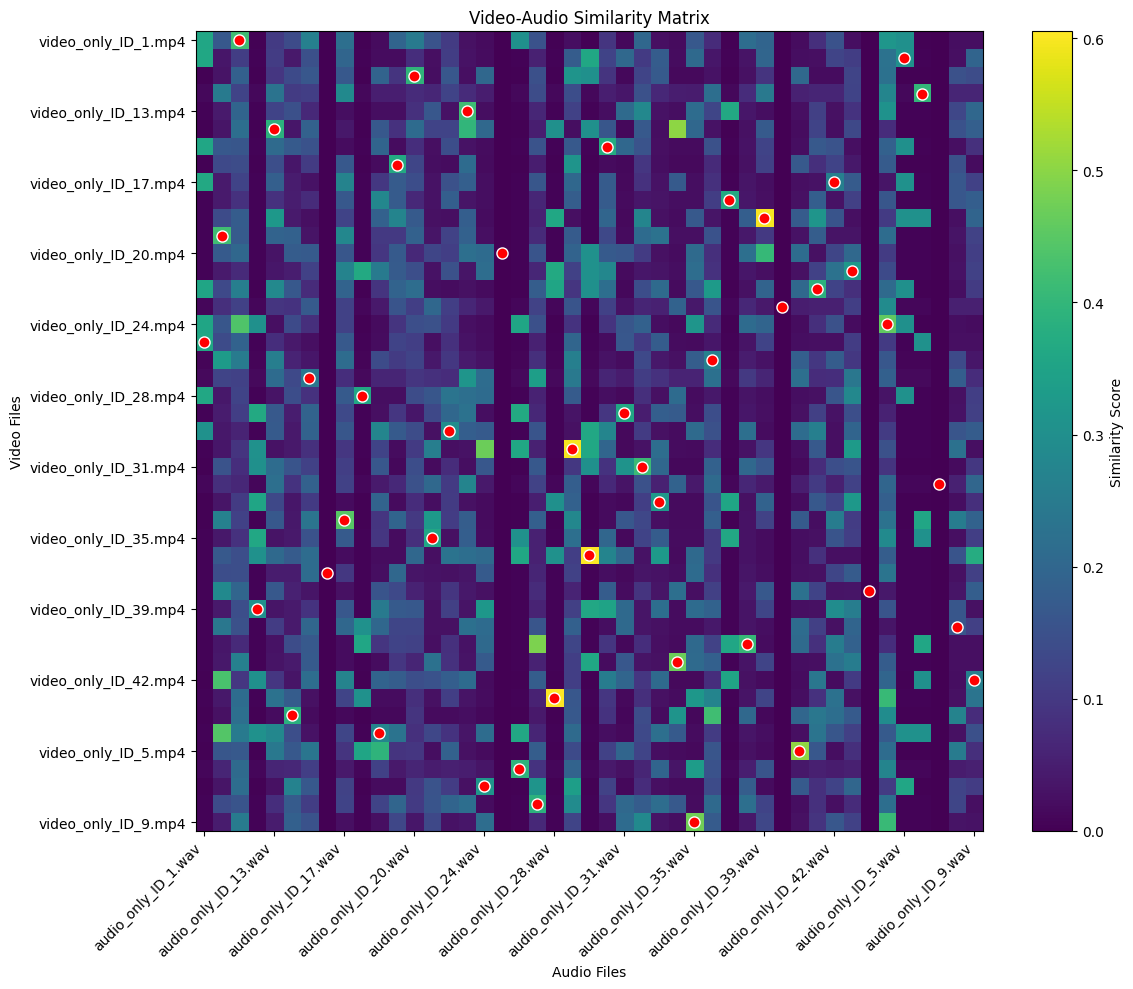

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity
import librosa
import glob
from scipy.optimize import linear_sum_assignment

# Set display options
plt.rcParams['figure.figsize'] = (12, 8)

#  Video Analysis Functions
def detect_ball_in_frame(frame):
    """Enhanced ball detection using both color thresholding and contour analysis"""
    # Resize frame for consistent processing
    frame = cv2.resize(frame, (640, 480))
    
    # Convert frame to HSV color space
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # Define range for blue color with wider tolerance
    lower_blue = np.array([90, 40, 40])
    upper_blue = np.array([140, 255, 255])
    
    # Create a mask for blue color
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Apply morphological operations to reduce noise
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # If contours are found, get the largest one (assuming it's the ball)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest_contour) > 30:  # Adjusted threshold
            # Use minimum enclosing circle for more accurate ball representation
            (x, y), radius = cv2.minEnclosingCircle(largest_contour)
            center = (int(x), int(y))
            radius = int(radius)
            
            # Verify circularity using contour area to circle area ratio
            contour_area = cv2.contourArea(largest_contour)
            circle_area = np.pi * radius * radius
            circularity = contour_area / circle_area if circle_area > 0 else 0
            
            if 0.7 < circularity < 1.3:  # Reasonable range for a ball
                return (center[0], center[1], radius)
    
    return None
def analyze_video(video_path):
    """Enhanced video analysis with better trajectory tracking and collision detection"""
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Define boundaries for collision detection
    boundary = {
        'x_min': 10,
        'x_max': width - 10,
        'y_min': 10,
        'y_max': height - 10
    }
    
    # Initialize lists to store data
    positions = []
    radii = []
    timestamps = []
    
    # Process each frame
    for frame_idx in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
        
        timestamp = frame_idx / fps
        ball_info = detect_ball_in_frame(frame)
        
        if ball_info:
            positions.append((ball_info[0], ball_info[1]))
            radii.append(ball_info[2])
            timestamps.append(timestamp)
    
    cap.release()
    
    # Convert to numpy arrays
    positions = np.array(positions)
    radii = np.array(radii)
    timestamps = np.array(timestamps)
    
    if len(positions) < 3:
        return {
            'video_path': video_path,
            'positions': positions,
            'timestamps': timestamps,
            'velocities': np.array([]),
            'accelerations': np.array([]),
            'collision_times': np.array([]),
            'collision_types': []
        }
    
    # Apply Savitzky-Golay filter to smooth positions
    if len(positions) >= 5:  # Need at least 5 points for the filter
        window_size = min(15, len(positions) - 2 if len(positions) % 2 == 0 else len(positions) - 1)
        window_size = window_size if window_size % 2 == 1 else window_size - 1  # Ensure window_size is odd
        if window_size >= 3:
            positions_smooth = np.zeros_like(positions, dtype=float)
            positions_smooth[:, 0] = savgol_filter(positions[:, 0], window_size, 2)
            positions_smooth[:, 1] = savgol_filter(positions[:, 1], window_size, 2)
            positions = positions_smooth
    
    # Calculate velocities (difference of positions)
    velocities = np.diff(positions, axis=0) / np.diff(timestamps)[:, np.newaxis]
    
    # Calculate accelerations (difference of velocities)
    accelerations = np.diff(velocities, axis=0) / np.diff(timestamps[:-1])[:, np.newaxis]
    
    # Enhanced collision detection using position, velocity changes, and boundary conditions
    collision_indices = []
    collision_types = []
    
    # First pass: detect using acceleration magnitude
    acc_magnitudes = np.linalg.norm(accelerations, axis=1)
    vel_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Adaptive threshold based on percentile
    acc_threshold = np.percentile(acc_magnitudes, 90)
    
    # Previous position and velocity for detecting direction changes
    prev_positions = positions[:-2]
    next_positions = positions[2:]
    prev_velocities = velocities[:-1]
    next_velocities = velocities[1:]
    
    # Detect collisions based on multiple criteria
    for i in range(len(accelerations)):
        # Current position and radius
        x, y = positions[i+1]
        radius = radii[i+1] if i+1 < len(radii) else 0
        
        # Check for high acceleration
        if acc_magnitudes[i] > acc_threshold:
            # Determine collision type based on position and velocity changes
            vx_prev, vy_prev = prev_velocities[i]
            vx_next, vy_next = next_velocities[i] if i < len(next_velocities) else (0, 0)
            
            # Left/Right wall collision: significant change in x-velocity
            if abs(vx_next + vx_prev) < 0.5 * abs(vx_next - vx_prev):
                if x - radius <= boundary['x_min'] + 5:
                    collision_indices.append(i)
                    collision_types.append('left')
                elif x + radius >= boundary['x_max'] - 5:
                    collision_indices.append(i)
                    collision_types.append('right')
            
            # Floor/Ceiling collision: significant change in y-velocity
            elif abs(vy_next + vy_prev) < 0.5 * abs(vy_next - vy_prev):
                if y - radius <= boundary['y_min'] + 5:
                    collision_indices.append(i)
                    collision_types.append('top')
                elif y + radius >= boundary['y_max'] - 5:
                    collision_indices.append(i)
                    collision_types.append('bottom')
            
            # Generic collision (fallback)
            else:
                collision_indices.append(i)
                collision_types.append('unknown')
    
    # Convert collision indices to timestamps
    collision_times = timestamps[1:-1][collision_indices] if collision_indices else np.array([])
    
    # Ensure collisions are not too close (minimum time between collisions)
    min_time_between_collisions = 0.08  # 80 ms
    filtered_collision_indices = []
    filtered_collision_types = []
    
    if len(collision_times) > 0:
        # Make sure collision_indices is not out of bounds
        if collision_indices[0] < len(timestamps[1:-1]):
            filtered_collision_indices.append(collision_indices[0])
            filtered_collision_types.append(collision_types[0])
        
        for i in range(1, len(collision_times)):
            # Check that the current index is valid and that filtered_collision_indices is not empty
            if i < len(collision_indices) and filtered_collision_indices and collision_indices[i] < len(timestamps[1:-1]):
                last_filtered_idx = filtered_collision_indices[-1]
                if last_filtered_idx < len(timestamps[1:-1]) and collision_indices[i] < len(timestamps[1:-1]):
                    last_time = timestamps[1:-1][last_filtered_idx]
                    current_time = timestamps[1:-1][collision_indices[i]]
                    if current_time - last_time > min_time_between_collisions:
                        filtered_collision_indices.append(collision_indices[i])
                        filtered_collision_types.append(collision_types[i])
    
    # Use the filtered indices to get the collision times
    filtered_collision_times = np.array([timestamps[1:-1][idx] for idx in filtered_collision_indices 
                                         if idx < len(timestamps[1:-1])]) if filtered_collision_indices else np.array([])
    
    return {
        'video_path': video_path,
        'positions': positions,
        'timestamps': timestamps,
        'velocities': velocities,
        'accelerations': accelerations,
        'collision_times': filtered_collision_times,
        'collision_types': filtered_collision_types
    }
'''
def analyze_video(video_path):
    """Enhanced video analysis with better trajectory tracking and collision detection"""
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Define boundaries for collision detection
    boundary = {
        'x_min': 10,
        'x_max': width - 10,
        'y_min': 10,
        'y_max': height - 10
    }
    
    # Initialize lists to store data
    positions = []
    radii = []
    timestamps = []
    
    # Process each frame
    for frame_idx in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
        
        timestamp = frame_idx / fps
        ball_info = detect_ball_in_frame(frame)
        
        if ball_info:
            positions.append((ball_info[0], ball_info[1]))
            radii.append(ball_info[2])
            timestamps.append(timestamp)
    
    cap.release()
    
    # Convert to numpy arrays
    positions = np.array(positions)
    radii = np.array(radii)
    timestamps = np.array(timestamps)
    
    if len(positions) < 3:
        return {
            'video_path': video_path,
            'positions': positions,
            'timestamps': timestamps,
            'velocities': np.array([]),
            'accelerations': np.array([]),
            'collision_times': np.array([]),
            'collision_types': []
        }
    
    # Apply Savitzky-Golay filter to smooth positions
    if len(positions) >= 5:  # Need at least 5 points for the filter
        window_size = min(15, len(positions) - 2 if len(positions) % 2 == 0 else len(positions) - 1)
        window_size = window_size if window_size % 2 == 1 else window_size - 1  # Ensure window_size is odd
        if window_size >= 3:
            positions_smooth = np.zeros_like(positions, dtype=float)
            positions_smooth[:, 0] = savgol_filter(positions[:, 0], window_size, 2)
            positions_smooth[:, 1] = savgol_filter(positions[:, 1], window_size, 2)
            positions = positions_smooth
    
    # Calculate velocities (difference of positions)
    velocities = np.diff(positions, axis=0) / np.diff(timestamps)[:, np.newaxis]
    
    # Calculate accelerations (difference of velocities)
    accelerations = np.diff(velocities, axis=0) / np.diff(timestamps[:-1])[:, np.newaxis]
    
    # Enhanced collision detection using position, velocity changes, and boundary conditions
    collision_indices = []
    collision_types = []
    
    # First pass: detect using acceleration magnitude
    acc_magnitudes = np.linalg.norm(accelerations, axis=1)
    vel_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Adaptive threshold based on percentile
    acc_threshold = np.percentile(acc_magnitudes, 90)
    
    # Previous position and velocity for detecting direction changes
    prev_positions = positions[:-2]
    next_positions = positions[2:]
    prev_velocities = velocities[:-1]
    next_velocities = velocities[1:]
    
    # Detect collisions based on multiple criteria
    for i in range(len(accelerations)):
        # Current position and radius
        x, y = positions[i+1]
        radius = radii[i+1] if i+1 < len(radii) else 0
        
        # Check for high acceleration
        if acc_magnitudes[i] > acc_threshold:
            # Determine collision type based on position and velocity changes
            vx_prev, vy_prev = prev_velocities[i]
            vx_next, vy_next = next_velocities[i] if i < len(next_velocities) else (0, 0)
            
            # Left/Right wall collision: significant change in x-velocity
            if abs(vx_next + vx_prev) < 0.5 * abs(vx_next - vx_prev):
                if x - radius <= boundary['x_min'] + 5:
                    collision_indices.append(i)
                    collision_types.append('left')
                elif x + radius >= boundary['x_max'] - 5:
                    collision_indices.append(i)
                    collision_types.append('right')
            
            # Floor/Ceiling collision: significant change in y-velocity
            elif abs(vy_next + vy_prev) < 0.5 * abs(vy_next - vy_prev):
                if y - radius <= boundary['y_min'] + 5:
                    collision_indices.append(i)
                    collision_types.append('top')
                elif y + radius >= boundary['y_max'] - 5:
                    collision_indices.append(i)
                    collision_types.append('bottom')
            
            # Generic collision (fallback)
            else:
                collision_indices.append(i)
                collision_types.append('unknown')
    
    # Convert collision indices to timestamps
    collision_times = timestamps[1:-1][collision_indices]
    
    # Ensure collisions are not too close (minimum time between collisions)
    min_time_between_collisions = 0.08  # 80 ms
    filtered_collision_indices = []
    filtered_collision_types = []
    
    if len(collision_times) > 0:
        filtered_collision_indices.append(collision_indices[0])
        filtered_collision_types.append(collision_types[0])
        
        for i in range(1, len(collision_times)):
            if collision_times[i] - collision_times[filtered_collision_indices[-1]] > min_time_between_collisions:
                filtered_collision_indices.append(collision_indices[i])
                filtered_collision_types.append(collision_types[i])
    
    filtered_collision_times = timestamps[1:-1][filtered_collision_indices]
    
    return {
        'video_path': video_path,
        'positions': positions,
        'timestamps': timestamps,
        'velocities': velocities,
        'accelerations': accelerations,
        'collision_times': filtered_collision_times,
        'collision_types': filtered_collision_types
    }
'''
# 2. Audio Analysis Functions
def analyze_audio(audio_path):
    """Enhanced audio analysis with better peak detection for beeps"""
    # Load audio file
    y, sr = librosa.load(audio_path, sr=None)
    
    # Calculate duration
    duration = len(y) / sr
    
    # Calculate envelope using root mean square energy
    frame_length = int(0.025 * sr)  # 25ms window
    hop_length = int(0.010 * sr)    # 10ms hop
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    
    # Convert RMS frame times to actual times
    rms_times = librosa.times_like(rms, sr=sr, hop_length=hop_length)
    
    # Normalize RMS
    rms = rms / np.max(rms) if np.max(rms) > 0 else rms
    
    # Apply dynamic threshold based on signal statistics
    mean_rms = np.mean(rms)
    std_rms = np.std(rms)
    threshold = mean_rms + 2 * std_rms
    
    # Find peaks in the RMS curve
    peaks, _ = find_peaks(rms, height=threshold, distance=int(0.1 * sr / hop_length))  # Minimum distance 100ms
    
    # Convert peak indices to timestamps
    peak_times = rms_times[peaks]
    
    # Filter out potential false positives based on peak prominence
    if len(peaks) > 0:
        prominences = rms[peaks] - mean_rms
        prominence_threshold = np.percentile(prominences, 50)  # Adaptive threshold
        peak_times = peak_times[prominences > prominence_threshold]
    
    return {
        'audio_path': audio_path,
        'signal': y,
        'sample_rate': sr,
        'rms': rms,
        'rms_times': rms_times,
        'peak_times': peak_times,
        'duration': duration
    }

# 3.  Matching Functions
def calculate_similarity_matrix(video_analyses, audio_analyses, tolerance=0.05):
    """Calculate similarity matrix between all video and audio files using multiple metrics"""
    # Initialize similarity matrix
    n_videos = len(video_analyses)
    n_audios = len(audio_analyses)
    similarity_matrix = np.zeros((n_videos, n_audios))
    
    for v_idx, video_data in enumerate(video_analyses):
        video_collisions = video_data['collision_times']
        
        for a_idx, audio_data in enumerate(audio_analyses):
            audio_peaks = audio_data['peak_times']
            
            if len(video_collisions) == 0 or len(audio_peaks) == 0:
                similarity_matrix[v_idx, a_idx] = 0
                continue
            
            # 1. Temporal pattern matching
            # Create binary vectors for events
            max_time = max(video_collisions[-1] if len(video_collisions) > 0 else 0, 
                          audio_peaks[-1] if len(audio_peaks) > 0 else 0)
            max_time += 1
            
            bins = np.arange(0, max_time + tolerance, tolerance)
            video_vector = np.zeros(len(bins)-1)
            audio_vector = np.zeros(len(bins)-1)
            
            for collision in video_collisions:
                bin_idx = min(int(collision / tolerance), len(video_vector)-1)
                video_vector[bin_idx] = 1
            
            for peak in audio_peaks:
                bin_idx = min(int(peak / tolerance), len(audio_vector)-1)
                audio_vector[bin_idx] = 1
            
            # Calculate cosine similarity
            cos_sim = cosine_similarity([video_vector], [audio_vector])[0][0]
            
            # 2. Event count similarity
            count_ratio = min(len(video_collisions), len(audio_peaks)) / max(len(video_collisions), len(audio_peaks)) if max(len(video_collisions), len(audio_peaks)) > 0 else 0
            
            # 3. Best alignment similarity using dynamic time warping approach
            dtw_sim = 0
            if len(video_collisions) > 0 and len(audio_peaks) > 0:
                # Calculate distance matrix between all collision and peak times
                dist_matrix = cdist(video_collisions.reshape(-1, 1), audio_peaks.reshape(-1, 1))
                
                # Count matches within tolerance
                matches = np.sum(dist_matrix < tolerance)
                max_possible = min(len(video_collisions), len(audio_peaks))
                dtw_sim = matches / max_possible if max_possible > 0 else 0
            
            # 4. Rhythm pattern similarity
            rhythm_sim = 0
            if len(video_collisions) > 1 and len(audio_peaks) > 1:
                # Calculate intervals between events
                video_intervals = np.diff(video_collisions)
                audio_intervals = np.diff(audio_peaks)
                
                # Normalize intervals to account for scaling differences
                video_intervals_norm = video_intervals / np.mean(video_intervals) if np.mean(video_intervals) > 0 else video_intervals
                audio_intervals_norm = audio_intervals / np.mean(audio_intervals) if np.mean(audio_intervals) > 0 else audio_intervals
                
                # Compute similarity based on interval patterns
                min_len = min(len(video_intervals_norm), len(audio_intervals_norm))
                if min_len > 0:
                    # Use correlation coefficient if we have enough data points
                    if min_len > 2:
                        video_intervals_sample = video_intervals_norm[:min_len]
                        audio_intervals_sample = audio_intervals_norm[:min_len]
                        interval_corr = np.corrcoef(video_intervals_sample, audio_intervals_sample)[0, 1]
                        rhythm_sim = max(0, interval_corr)  # Only consider positive correlation
                    else:
                        # For very few intervals, use relative difference
                        rhythm_sim = 1 - min(1, abs(np.mean(video_intervals) - np.mean(audio_intervals)) / max(np.mean(video_intervals), np.mean(audio_intervals)))
                        # Combine all similarity metrics with appropriate weights
            combined_sim = 0.35 * cos_sim + 0.20 * count_ratio + 0.30 * dtw_sim + 0.15 * rhythm_sim
            
            similarity_matrix[v_idx, a_idx] = combined_sim
    
    return similarity_matrix

def match_using_hungarian_algorithm(similarity_matrix):
    """Use the Hungarian algorithm to find optimal matching between videos and audios"""
    # Convert similarity matrix to cost matrix (Hungarian algorithm minimizes cost)
    cost_matrix = 1 - similarity_matrix
    
    # Apply Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create matches list
    matches = []
    for i, j in zip(row_ind, col_ind):
        matches.append({
            'video_idx': i,
            'audio_idx': j,
            'similarity': similarity_matrix[i, j]
        })
    
    return matches


def process_all_videos(video_dir):
    """Process all videos in the directory with improved analysis"""
    video_files = sorted(glob.glob(os.path.join(video_dir, '*.mp4')))
    video_analyses = []
    
    print(f"Found {len(video_files)} video files.")
    
    for i, video_path in enumerate(video_files):
        print(f"Processing video {i+1}/{len(video_files)}: {os.path.basename(video_path)}")
        video_data = analyze_video(video_path)
        video_analyses.append(video_data)
        
        # Print summary of detected collisions
        print(f"  - Detected {len(video_data['collision_times'])} collisions")
    
    return video_analyses

def process_all_audio(audio_dir):
    """Process all audio files in the directory with analysis"""
    audio_files = sorted(glob.glob(os.path.join(audio_dir, '*.wav')))
    audio_analyses = []
    
    print(f"Found {len(audio_files)} audio files.")
    
    for i, audio_path in enumerate(audio_files):
        print(f"Processing audio {i+1}/{len(audio_files)}: {os.path.basename(audio_path)}")
        audio_data = analyze_audio(audio_path)
        audio_analyses.append(audio_data)
        
        # Print summary of detected peaks
        print(f"  - Detected {len(audio_data['peak_times'])} audio peaks")
    
    return audio_analyses

def create_final_matches(video_analyses, audio_analyses, matches):
    """Create final matches DataFrame based on Hungarian algorithm results"""
    final_matches = []
    
    for match in matches:
        video_idx = match['video_idx']
        audio_idx = match['audio_idx']
        similarity = match['similarity']
        
        video_path = video_analyses[video_idx]['video_path']
        audio_path = audio_analyses[audio_idx]['audio_path']
        
        final_matches.append({
            'audio_path': audio_path,
            'video_path': video_path,
            'similarity': similarity
        })
    
    return pd.DataFrame(final_matches)

def main(video_dir='video_only', audio_dir='audio_only', output_csv='matches2.csv'):
    
    print("Starting enhanced ball motion and audio matching process...")
    
    
    print("\n--- VIDEO ANALYSIS ---")
    video_analyses = process_all_videos(video_dir)
    
    
    print("\n--- AUDIO ANALYSIS ---")
    audio_analyses = process_all_audio(audio_dir)
    
    # Calculate similarity matrix using multiple metrics
    print("\n--- MATCHING PROCESS ---")
    print("Calculating similarity matrix...")
    similarity_matrix = calculate_similarity_matrix(video_analyses, audio_analyses)
    
    # Apply Hungarian algorithm for optimal matching
    print("Applying Hungarian algorithm for optimal matching...")
    matches = match_using_hungarian_algorithm(similarity_matrix)
    
    # Create final matches DataFrame
    matches_df = create_final_matches(video_analyses, audio_analyses, matches)
    
    # Sort by similarity score
    matches_df = matches_df.sort_values('similarity', ascending=False)
    
    # Prepare output CSV
    output_df = pd.DataFrame({
        'audio_file': matches_df['audio_path'].apply(os.path.basename),
        'video_file': matches_df['video_path'].apply(os.path.basename)
    })
    
    # Save to CSV
    output_df.to_csv(output_csv, index=False)
    print(f"Matches saved to {output_csv}")
    
    # Evaluate matching results
    match_details = evaluate_matches(matches_df, video_analyses, audio_analyses)
    print("\n--- MATCH EVALUATION ---")
    print(f"Average similarity score: {match_details['similarity'].mean():.4f}")
    print(f"Median similarity score: {match_details['similarity'].median():.4f}")
    
    # Print top and bottom matches
    print("\nTop 5 matches:")
    for _, row in match_details.sort_values('similarity', ascending=False).head(5).iterrows():
        print(f"  {row['video_file']} <-> {row['audio_file']} (similarity: {row['similarity']:.4f})")
    
    print("\nBottom 5 matches:")
    for _, row in match_details.sort_values('similarity', ascending=True).head(5).iterrows():
        print(f"  {row['video_file']} <-> {row['audio_file']} (similarity: {row['similarity']:.4f})")
    
    return {
        'video_analyses': video_analyses,
        'audio_analyses': audio_analyses,
        'similarity_matrix': similarity_matrix,
        'matches': matches,
        'matches_df': matches_df,
        'match_details': match_details
    }

# 5.  Visualization and Evaluation Functions
def visualize_match(video_data, audio_data, similarity, title=None):
    """Enhanced visualization of a matched pair of video and audio"""
    fig, axs = plt.subplots(4, 1, figsize=(14, 16))
    
    # 1. Plot ball position and collisions
    if len(video_data['positions']) > 0:
        axs[0].plot(video_data['timestamps'], video_data['positions'][:, 1], label='Y Position')
        axs[0].set_title('Ball Y Position and Detected Collisions')
        axs[0].set_xlabel('Time (s)')
        axs[0].set_ylabel('Y Position (pixels)')
        axs[0].grid(True)
        
        # Mark different types of video collisions with different colors
        if len(video_data.get('collision_types', [])) > 0:
            for i, col_time in enumerate(video_data['collision_times']):
                col_type = video_data['collision_types'][i]
                color = {'left': 'r', 'right': 'g', 'top': 'b', 'bottom': 'm', 'unknown': 'k'}.get(col_type, 'k')
                axs[0].axvline(x=col_time, color=color, linestyle='--', alpha=0.7)
                axs[0].text(col_time, axs[0].get_ylim()[0], col_type[0].upper(), 
                           color=color, fontsize=8, ha='center')
        else:
            # Default collision marking if types not available
            for col_time in video_data['collision_times']:
                axs[0].axvline(x=col_time, color='r', linestyle='--', alpha=0.5)
    
    # 2. Plot audio waveform and detected peaks
    if hasattr(audio_data, 'signal') and len(audio_data['signal']) > 0:
        time = np.linspace(0, audio_data['duration'], len(audio_data['signal']))
        axs[1].plot(time, audio_data['signal'], 'b-', alpha=0.7)
        axs[1].set_title('Audio Waveform and Detected Peaks')
        axs[1].set_xlabel('Time (s)')
        axs[1].set_ylabel('Amplitude')
        
        # Mark audio peaks
        for peak_time in audio_data['peak_times']:
            axs[1].axvline(x=peak_time, color='r', linestyle='--', alpha=0.7)
        
        axs[1].grid(True)
    
    # 3. Plot audio RMS energy and peaks
    if 'rms' in audio_data and len(audio_data['rms']) > 0:
        axs[2].plot(audio_data['rms_times'], audio_data['rms'], 'g-')
        axs[2].set_title('Audio RMS Energy and Peaks')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylabel('RMS Energy')
        
        # Mark audio peaks
        for peak_time in audio_data['peak_times']:
            closest_idx = np.argmin(np.abs(audio_data['rms_times'] - peak_time))
            if closest_idx < len(audio_data['rms']):
                peak_value = audio_data['rms'][closest_idx]
                axs[2].plot(peak_time, peak_value, 'ro')
        
        axs[2].grid(True)
    
    # 4. Comparison view for alignment
    axs[3].set_title('Comparison of Video Collisions and Audio Peaks')
    axs[3].set_xlabel('Time (s)')
    axs[3].set_yticks([0, 1])
    axs[3].set_yticklabels(['Video', 'Audio'])
    axs[3].grid(True)
    
    # Plot timeline
    max_time = max(
        video_data['timestamps'][-1] if len(video_data['timestamps']) > 0 else 0,
        audio_data['duration'] if 'duration' in audio_data else 0
    )
    axs[3].set_xlim([0, max_time])
    
    # Plot video collisions
    for col_time in video_data['collision_times']:
        axs[3].plot([col_time, col_time], [-0.1, 0.4], 'r-', linewidth=2)
    
    # Plot audio peaks
    for peak_time in audio_data['peak_times']:
        axs[3].plot([peak_time, peak_time], [0.6, 1.1], 'b-', linewidth=2)
    
    # Draw matching lines for close events
    tolerance = 0.1  # 100ms tolerance
    for col_time in video_data['collision_times']:
        for peak_time in audio_data['peak_times']:
            if abs(col_time - peak_time) < tolerance:
                axs[3].plot([col_time, peak_time], [0.3, 0.7], 'g--', alpha=0.5)
    
    if title:
        fig.suptitle(f"{title} (Similarity: {similarity:.4f})", fontsize=16)
    
    plt.tight_layout()
    return fig

def evaluate_matches(matches_df, video_analyses, audio_analyses):
    """Enhanced evaluation of matches quality"""
    match_details = []
    
    for _, row in matches_df.iterrows():
        audio_path = row['audio_path']
        video_path = row['video_path']
        similarity = row['similarity']
        
        # Find corresponding analyses
        video_data = next((v for v in video_analyses if v['video_path'] == video_path), None)
        audio_data = next((a for a in audio_analyses if a['audio_path'] == audio_path), None)
        
        if video_data and audio_data:
            # Count collisions and peaks
            num_video_collisions = len(video_data['collision_times'])
            num_audio_peaks = len(audio_data['peak_times'])
            
            # Calculate time offset that would maximize alignment
            time_offsets = []
            
            if num_video_collisions > 0 and num_audio_peaks > 0:
                # Try different offsets and calculate number of aligned events
                for offset in np.linspace(-1.0, 1.0, 101):  # Try offsets from -1s to +1s
                    aligned_count = 0
                    for col_time in video_data['collision_times']:
                        adjusted_time = col_time + offset
                        # Check if any audio peak is within tolerance of the adjusted collision time
                        for peak_time in audio_data['peak_times']:
                            if abs(adjusted_time - peak_time) < 0.1:  # 100ms tolerance
                                aligned_count += 1
                                break
                    
                    time_offsets.append((offset, aligned_count))
                
                # Find best offset
                best_offset, best_aligned = max(time_offsets, key=lambda x: x[1])
                alignment_ratio = best_aligned / min(num_video_collisions, num_audio_peaks) if min(num_video_collisions, num_audio_peaks) > 0 else 0
            else:
                best_offset = 0
                best_aligned = 0
                alignment_ratio = 0
            
            match_details.append({
                'audio_file': os.path.basename(audio_path),
                'video_file': os.path.basename(video_path),
                'similarity': similarity,
                'video_collisions': num_video_collisions,
                'audio_peaks': num_audio_peaks,
                'collision_diff': abs(num_video_collisions - num_audio_peaks),
                'best_offset': best_offset,
                'aligned_events': best_aligned,
                'alignment_ratio': alignment_ratio
            })
    
    match_details_df = pd.DataFrame(match_details)
    return match_details_df

def visualize_similarity_matrix(similarity_matrix, video_analyses, audio_analyses):
    """Visualize the similarity matrix as a heatmap"""
    plt.figure(figsize=(12, 10))
    
    # Get video and audio file names for labels
    video_labels = [os.path.basename(v['video_path']) for v in video_analyses]
    audio_labels = [os.path.basename(a['audio_path']) for a in audio_analyses]
    
    # Create heatmap
    plt.imshow(similarity_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Similarity Score')
    
    # Add labels and title
    plt.title('Video-Audio Similarity Matrix')
    plt.xlabel('Audio Files')
    plt.ylabel('Video Files')
    
    # Set tick labels (use subset for readability if too many)
    if len(video_labels) <= 10:
        plt.yticks(range(len(video_labels)), video_labels)
    else:
        plt.yticks(range(0, len(video_labels), len(video_labels)//10), 
                  [video_labels[i] for i in range(0, len(video_labels), len(video_labels)//10)])
    
    if len(audio_labels) <= 10:
        plt.xticks(range(len(audio_labels)), audio_labels, rotation=45, ha='right')
    else:
        plt.xticks(range(0, len(audio_labels), len(audio_labels)//10), 
                  [audio_labels[i] for i in range(0, len(audio_labels), len(audio_labels)//10)], 
                  rotation=45, ha='right')
        # Mark optimal matches from Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(1 - similarity_matrix)
    for i, j in zip(row_ind, col_ind):
        plt.plot(j, i, 'ro', markersize=8, markeredgecolor='white')
    
    plt.tight_layout()
    return plt.gcf()

# Run the main function
if __name__ == "__main__":
    results = main()
    
    # Create visualizations for top matches
    print("\n--- CREATING VISUALIZATIONS ---")
    top_matches = results['matches_df'].head(3)
    
    for i, (_, match) in enumerate(top_matches.iterrows()):
        video_data = next((v for v in results['video_analyses'] if v['video_path'] == match['video_path']), None)
        audio_data = next((a for a in results['audio_analyses'] if a['audio_path'] == match['audio_path']), None)
        
        if video_data and audio_data:
            title = f"Match {i+1}: {os.path.basename(video_data['video_path'])} and {os.path.basename(audio_data['audio_path'])}"
            fig = visualize_match(video_data, audio_data, match['similarity'], title)
            fig.savefig(f"match_{i+1}_visualization.png", dpi=300, bbox_inches='tight')
            print(f"Saved visualization for match {i+1}")
    
    # Visualize similarity matrix
    sim_matrix_fig = visualize_similarity_matrix(results['similarity_matrix'], 
                                               results['video_analyses'], 
                                               results['audio_analyses'])
    sim_matrix_fig.savefig("similarity_matrix.png", dpi=300, bbox_inches='tight')
    print("Saved similarity matrix visualization")
    
    print("\nProcess completed successfully.")

In [4]:
!pip install moviepy==1.0.3

Could not fetch URL https://pypi.org/simple/moviepy/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/moviepy/ (Caused by SSLError(SSLCertVerificationError("The certificate's CN name does not match the passed value."))) - skipping


ERROR: Could not find a version that satisfies the requirement moviepy==1.03 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for moviepy==1.03
